# AI-Powered Financial Fraud Detection and Risk Analysis System

# Notebook 3: Isolation Forest Model

## Objective

This notebook trains an Isolation Forest model to detect anomalous financial transactions, evaluates its performance, generates fraud risk scores, and saves the trained model for deployment in the Streamlit dashboard.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import joblib

pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


## Load Processed Dataset

In [2]:
df = pd.read_csv("../data/processed/cleaned_transactions.csv")
print(df.shape)
df.head()

(283726, 34)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Scaled_Amount,Hour,Time_Period
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.244200,0,Night
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.342584,0,Night
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.158900,0,Night
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.139886,0,Night
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.073813,0,Night


## Prepare Features

In [3]:
features = df.drop(columns=["Class"])

categorical_cols = features.select_dtypes(include=["object"]).columns

if len(categorical_cols):
    features = pd.get_dummies(features, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()
X = scaler.fit_transform(features)
y = df["Class"]

## Train Isolation Forest

In [4]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.002,
    random_state=42,
    n_jobs=-1
)

iso.fit(X)

print("Model trained successfully.")

Model trained successfully.


## Predictions

In [5]:
pred = iso.predict(X)

pred = np.where(pred == -1, 1, 0)

df["Prediction"] = pred

df[["Class","Prediction"]].head()

,Class,Prediction
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


## Evaluation

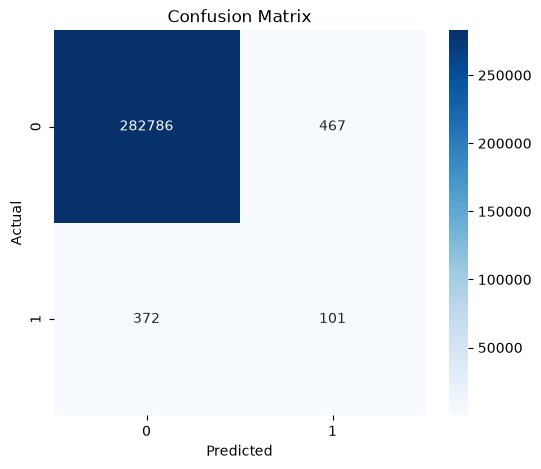

              precision    recall  f1-score   support

           0     0.9987    0.9984    0.9985    283253
           1     0.1778    0.2135    0.1940       473

    accuracy                         0.9970    283726
   macro avg     0.5883    0.6059    0.5963    283726
weighted avg     0.9973    0.9970    0.9972    283726

Precision : 0.1778
Recall    : 0.2135
F1 Score  : 0.1940
ROC-AUC   : 0.9474


In [6]:
cm = confusion_matrix(y,pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y,pred,digits=4))

precision = precision_score(y,pred)
recall = recall_score(y,pred)
f1 = f1_score(y,pred)

scores = -iso.score_samples(X)
auc = roc_auc_score(y,scores)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

## Fraud Risk Score

In [7]:
raw_scores = -iso.score_samples(X)

risk = (raw_scores-raw_scores.min())/(raw_scores.max()-raw_scores.min())*100

df["Risk_Score"] = risk.round(2)

def risk_level(score):
    if score < 30:
        return "Low"
    elif score < 70:
        return "Medium"
    return "High"

df["Risk_Level"] = df["Risk_Score"].apply(risk_level)

def recommendation(level):
    if level=="High":
        return "Block Transaction"
    elif level=="Medium":
        return "Manual Verification"
    return "Approve"

df["Recommendation"] = df["Risk_Level"].apply(recommendation)

df[["Prediction","Risk_Score","Risk_Level","Recommendation"]].head()

,Prediction,Risk_Score,Risk_Level,Recommendation
0,0,18.19,Low,Approve
1,0,11.56,Low,Approve
2,0,38.45,Medium,Manual Verification
3,0,22.67,Low,Approve
4,0,18.86,Low,Approve


## Visualizations

In [8]:
fig = px.histogram(
    df,
    x="Risk_Score",
    color="Prediction",
    nbins=50,
    title="Risk Score Distribution"
)
fig.show()

fig = px.scatter(
    df.sample(min(5000,len(df)), random_state=42),
    x="Amount",
    y="Risk_Score",
    color="Prediction",
    title="Amount vs Risk Score"
)
fig.show()

## Top High Risk Transactions

In [9]:
df.sort_values("Risk_Score",ascending=False)[
    ["Amount","Class","Prediction","Risk_Score","Risk_Level","Recommendation"]
].head(20)

,Amount,Class,Prediction,Risk_Score,Risk_Level,Recommendation
273745,25691.16,0,1,100.00,High,Block Transaction
150705,18910.00,0,1,96.68,High,Block Transaction
58220,19656.53,0,1,94.03,High,Block Transaction
172698,4861.64,0,1,93.37,High,Block Transaction
46641,12910.93,0,1,93.11,High,Block Transaction
39590,1201.83,0,1,92.86,High,Block Transaction
219306,5964.95,0,1,92.78,High,Block Transaction
172401,4543.64,0,1,92.69,High,Block Transaction
261415,2074.69,0,1,92.22,High,Block Transaction
227878,7367.00,0,1,91.68,High,Block Transaction


## Save Model

In [10]:
joblib.dump(iso,"../models/isolation_forest.pkl")
joblib.dump(scaler,"../models/scaler.pkl")

df.to_csv("../data/processed/isolation_forest_predictions.csv",index=False)

print("Model, scaler and prediction file saved successfully.")

Model, scaler and prediction file saved successfully.


# Business Insights

- Isolation Forest identifies anomalous transaction patterns without requiring balanced classes.
- Each transaction receives a continuous risk score.
- Risk scores can drive dashboard alerts and prioritization.
- High-risk transactions should be reviewed before approval.


# Conclusion

This notebook successfully trained an Isolation Forest anomaly detection model, evaluated its performance, generated fraud risk scores, and exported the model artifacts for dashboard deployment.

**Next Notebook:** AutoEncoder-based anomaly detection.
